# EDA 1 — cada dataset

Visão geral e padrões de cada base, uma de cada vez. A análise das bases juntas, com o equilíbrio do treino, da validação e do teste, está em `eda_2_conjunto.ipynb`.

| Dataset | Linhas | Verdadeiras | Enganosas (meio) | Falsas | Período | O que é |
|---|---:|---:|---:|---:|---|---|
| Fake.br | 7.181 | 3.583 | 0 | 3.598 | 2016–2018 | pares falsa × verdadeira do mesmo assunto (NILC/USP); só texto longo, cortado no tamanho do par |
| FakeRecogna | 4.382 | 1.917 | 0 | 2.465 | 2019–2021 | boatos do Boatos.org × matérias do G1, UOL e Extra (UNESP), texto recoletado |
| FakeTrue.Br | 2.142 | 1.330 | 0 | 812 | 2018–2022 (maioria) | pares Boatos.org × G1/Folha/UOL do mesmo assunto; texto em minúsculas |
| Fact Check API | 10.341 | 94 | 3.122 | 7.125 | 2018–2026 | alegações com veredito de 10 agências brasileiras (Google Fact Check Tools) |
| FakenewsBR (agências) | 16.729 | 603 | 555 | 15.571 | 2016–2026 | alegações checadas por agências (e-farsas, G1 Fato ou Fake, Lupa...); falsos amostrados |
| FakenewsBR (mensagens) | 7.082 | 3.928 | 3 | 3.151 | 2018 e 2020 | mensagens de WhatsApp (eleição 2018) e de COVID anotadas; sem veredito |
| Portais | 21.222 | 21.222 | 0 | 0 | 2018–2026 | matérias de 9 portais de linhas editoriais variadas; verdadeiras por suposição |
| **Total** | **69.083** | **32.679** | **3.680** | **32.724** | | |

Linhas = registros no `dataset.jsonl`, depois de tirar duplicatas. Uso no modelo do jogo
(protocolo B, `split_produto`), depois do equilíbrio:

| Split | Verdadeiras | Enganosas | Falsas | Regra |
|---|---:|---:|---:|---|
| `treino` | 12.512 | 1.541 | 12.512 | pareadas 80%; checagens e portais até 2023; mensagens |
| `validacao` | 1.446 | 964 | 1.446 | pareadas 10%; checagens e portais de 2024 |
| `teste` | 1.638 | 1.092 | 1.638 | pareadas 10%; checagens e portais de 2025 em diante |

O que sobra no equilíbrio vira `reserva` (32.164 registros, quase todos portais e falsos da
FakenewsBR); sem data, anteriores a 2016 ou quase-duplicatas viram `fora` (2.130).
Contagem de 05/10/2026, gerada por `pesquisa/dados/preparar_dados.py`.

In [1]:
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
CLASSES = ["verdadeiro", "enganoso", "falso"]
CORES = {"verdadeiro": "#2a78d6", "enganoso": "#e0a030", "falso": "#eb6834"}
TINTA_2 = "#52514e"
SPLITS = ["treino", "validacao", "teste"]
DATASETS = ["Fake.br", "FakeRecogna", "FakeTrue.Br", "Fact Check API",
            "FakenewsBR (agências)", "FakenewsBR (mensagens)", "Portais"]
MENSAGENS = {"FakeWhatsApp.BR_2018", "COVID19.BR"}
plt.rcParams.update({
    "figure.dpi": 110, "figure.figsize": (9, 3.6), "axes.spines.top": False,
    "axes.spines.right": False, "axes.grid": True, "grid.color": "#e6e5e0",
    "grid.linewidth": 0.8, "axes.axisbelow": True, "axes.edgecolor": "#b8b7b0",
    "axes.labelcolor": TINTA_2, "xtick.color": TINTA_2, "ytick.color": TINTA_2,
    "axes.titlesize": 12, "axes.titleweight": "bold", "axes.titlelocation": "left",
    "legend.frameon": False,
})
pd.set_option("display.max_colwidth", 300)
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", 250)

df = pd.read_json(RAIZ / "data" / "processed" / "dataset.jsonl", lines=True, dtype={"par_id": "Int64"})
NOMES = {"fakebr": "Fake.br", "fakerecogna": "FakeRecogna", "faketrue": "FakeTrue.Br",
         "factcheck": "Fact Check API", "verdadeiras": "Portais"}
df["dataset"] = df.base.map(NOMES)
fnb = df.base.eq("fakenewsbr")
df.loc[fnb & df.fonte.isin(MENSAGENS), "dataset"] = "FakenewsBR (mensagens)"
df.loc[fnb & ~df.fonte.isin(MENSAGENS), "dataset"] = "FakenewsBR (agências)"
df["data"] = pd.to_datetime(df["data"], errors="coerce")
df["ano"] = df.data.dt.year.astype("Int64")
df["tem_curto"] = df.texto_curto.notna()
curto = df.texto_curto.fillna("")
palavras = df.texto.str.findall(r"\w+")
df["palavras"] = palavras.str.len()
df["palavras_curto"] = curto.str.split().str.len()
df["% caixa alta"] = palavras.apply(lambda p: 100 * sum(w.isupper() and len(w) > 1 for w in p) / max(len(p), 1))
df["tem !"] = df.texto.str.contains("!", regex=False)
df["curto termina com ponto"] = curto.str.rstrip().str.endswith(".")
df["curto começa com vídeo/foto"] = curto.str.match(r"\W*(v[íi]deo|foto)", case=False)
df["curto em minúsculas"] = curto.ne("") & curto.eq(curto.str.lower())
print(f"{len(df):,} registros".replace(",", "."))

69.934 registros


In [2]:
# Campos do dataset.jsonl (ver o topo de pesquisa/dados/preparar_dados.py).
CAMPOS = ["titulo", "texto_curto", "texto", "data", "autor", "url", "categoria",
          "veredito_original", "par_id"]
COLUNAS_TABELA = ["id", "veracidade", "titulo", "texto_curto", "texto", "fonte", "data",
                  "split_produto"]


def perfil(nome):
    d = df[df.dataset == nome]
    classes = [c for c in CLASSES if (d.veracidade == c).any()]
    visao = pd.DataFrame({
        "linhas": d.veracidade.value_counts().reindex(classes),
        "período": d.groupby("veracidade").ano.agg(lambda s: f"{s.min()}–{s.max()}" if s.notna().any() else "—"),
        "sem data": d.groupby("veracidade").ano.agg(lambda s: int(s.isna().sum())),
        "com texto curto (%)": d.groupby("veracidade").tem_curto.mean().mul(100).round(0),
        "palavras do texto (mediana)": d.groupby("veracidade").palavras.median(),
        "palavras do texto curto (mediana)": d[d.tem_curto].groupby("veracidade").palavras_curto.median(),
    }).reindex(classes)
    visao.loc["total"] = [len(d), f"{d.ano.min()}–{d.ano.max()}", int(d.ano.isna().sum()),
                          round(100 * d.tem_curto.mean()), d.palavras.median(), d[d.tem_curto].palavras_curto.median()]
    display(visao)

    fig, ax = plt.subplots(figsize=(9, 2.8))
    por_ano = d.groupby(["ano", "veracidade"]).size().unstack(fill_value=0).reindex(columns=classes, fill_value=0)
    base = np.zeros(len(por_ano))
    for c in classes:
        ax.bar(por_ano.index.astype(int), por_ano[c], bottom=base, color=CORES[c], label=c, width=0.7)
        base += por_ano[c].values
    ax.set_title(f"{nome}: registros por ano")
    ax.legend(loc="upper left")
    ax.grid(axis="x", visible=False)
    plt.show()

    formato = d.groupby("veracidade")[["% caixa alta", "tem !", "curto termina com ponto",
                                        "curto começa com vídeo/foto", "curto em minúsculas"]].mean()
    formato.iloc[:, 1:] *= 100
    print("Formato (% dos registros, exceto a 1ª coluna, que é a média de % de palavras em CAIXA ALTA):")
    display(formato.reindex(classes).round(1))

    print("Fontes mais frequentes por classe:")
    display(pd.concat({c: d[d.veracidade == c].fonte.value_counts().head(4) for c in classes})
            .rename("registros").to_frame())

    print("Uso no modelo do jogo (split_produto):")
    display(d.pivot_table(index="veracidade", columns="split_produto", values="id", aggfunc="size", fill_value=0)
            .reindex(index=classes, columns=[c for c in SPLITS + ["reserva", "fora"] if c in set(d.split_produto)]))

    print("Campos preenchidos (% dos registros):")
    preenchido = d[CAMPOS].apply(lambda s: s.notna() & s.astype(str).str.strip().ne(""))
    display(preenchido.groupby(d.veracidade).mean().mul(100).round(0).reindex(classes))

    print("Tabela: 5 registros por classe, como estão no dataset.jsonl (texto cortado em 300 caracteres):")
    amostra = pd.concat([d[d.veracidade == c].sample(min(5, (d.veracidade == c).sum()), random_state=1)
                         for c in classes])
    tabela = amostra[COLUNAS_TABELA].copy()
    tabela["texto"] = tabela.texto.str[:300] + "…"
    tabela["data"] = tabela.data.dt.date
    display(tabela.set_index("id"))

## 1. Fake.br

**O que é.** Corpus do NILC/USP com 3.600 pares de notícias falsas e verdadeiras sobre o
mesmo assunto, coletadas em 2016–2018. Lido do repositório original (commit `780f551`).

**Padrões.**
- **Só texto longo**: nenhum registro tem texto curto. Para o modelo de frases curtas, o
  Fake.br só conta se uma afirmação for extraída de cada matéria (LLM).
- **Versão normalizada**: usamos `size_normalized_texts`, a versão que o corpus recomenda
  para treino. Em cada par, o texto mais longo é cortado no tamanho do mais curto. No
  `full_texts`, as verdadeiras tinham mediana de ~920 palavras e as falsas ~160; aqui, as
  duas ficam em ~157. Os pares 586, 697, 1468 e 1607 ficam de fora, porque a numeração
  das duas versões não bate neles.
- **Fonte**: 93% das falsas vêm de um único site (`diariodobrasil.org`); as verdadeiras, de
  G1 e Estadão.
- **Pares**: o sorteio 80/10/10 é por par, então as duas notícias do mesmo assunto ficam
  sempre do mesmo lado.

,linhas,período,sem data,com texto curto (%),palavras do texto (mediana),palavras do texto curto (mediana)
veracidade,,,,,,
verdadeiro,3583,2009–2018,2,0.0,160.0,NaN
falso,3598,2012–2018,1,0.0,157.0,NaN
total,7181,2009–2018,3,0.0,159.0,NaN


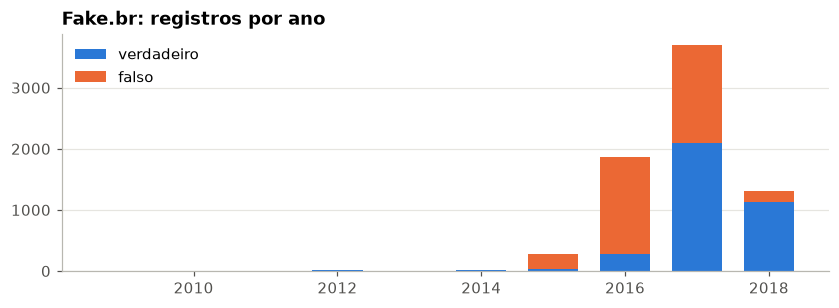

Formato (% dos registros, exceto a 1ª coluna, que é a média de % de palavras em CAIXA ALTA):


,% caixa alta,tem !,curto termina com ponto,curto começa com vídeo/foto,curto em minúsculas
veracidade,,,,,
verdadeiro,1.7,6.8,0.0,0.0,0.0
falso,1.8,33.3,0.0,0.0,0.0


Fontes mais frequentes por classe:


registros
           fonte                                  
verdadeiro g1.globo.com                       2287
           politica.estadao.com.br             749
           internacional.estadao.com.br        114
           cultura.estadao.com.br               95
falso      diariodobrasil.org                 3335
           afolhabrasil.com.br                 174
           thejornalbrasil.com.br               66
           ceticismopolitico.com                16

Uso no modelo do jogo (split_produto):


split_produto,treino,validacao,teste,reserva,fora
veracidade,,,,,
verdadeiro,2863,375,344,0,1
falso,2876,260,145,315,2


Campos preenchidos (% dos registros):


,titulo,texto_curto,texto,data,autor,url,categoria,veredito_original,par_id
veracidade,,,,,,,,,
verdadeiro,0.0,0.0,100.0,100.0,98.0,100.0,100.0,0.0,100.0
falso,0.0,0.0,100.0,100.0,2.0,100.0,100.0,0.0,100.0


Tabela: 5 registros por classe, como estão no dataset.jsonl (texto cortado em 300 caracteres):


,veracidade,titulo,texto_curto,texto,fonte,data,split_produto
id,,,,,,,
fakebr-true-1878,verdadeiro,NaN,NaN,"Nova lei desobriga salão de beleza a contratar profissionais como CLT. Lei legaliza contratação de manicure e cabeleireiro como autônomo e pagamento por comissão; medida é reforma trabalhista fatiada, diz especialista.. A chamada ""Lei do Salão Parceiro"" passa a regulamentar uma prática bem conhe...",g1.globo.com,2016-10-27,treino
fakebr-true-822,verdadeiro,NaN,NaN,"EUA apoiam cúpula para negociar fim do programa nuclear da Coreia do Norte. Governo sul-coreano anuncia que funcionários de alto escalão dos dois países se encontrarão em abril; presidente americano, Donald Trump, elogia esforço diplomático entre velhos inimigos. SEUL - Após meses de tensão entr...",internacional.estadao.com.br,2018-03-06,treino
fakebr-true-95,verdadeiro,NaN,NaN,"Senado aprova parcelamento de dívidas previdenciárias de produtores rurais Pelo projeto, poderão ser quitados os débitos vencidos até 30 de agosto deste ano. Adesão ao programa será aceita até 28 de fevereiro de 2018. O Senado aprovou nesta quinta-feira (14) um projeto que prevê o parcelamento d...",g1.globo.com,2017-12-14,treino
fakebr-true-1230,verdadeiro,NaN,NaN,"Associação de juízes sugere que Gilmar Mendes renuncie e vire comentarista. Para entidade, ministro do STF vem reiteradamente violando as leis da magistratura e os deveres éticos impostos a todos os juízes do país.. A Associação dos Juízes Federais de São Paulo e Mato Grosso do Sul divulgou nota...",g1.globo.com,2016-12-15,treino
fakebr-true-1667,verdadeiro,NaN,NaN,"Quatro pessoas ficam feridas em acidente entre carro e caminhão na BR-376. Motorista do automóvel sofreu ferimentos graves e foi resgatado pelo helicóptero do Samu nesta terça-feira (23). Em Sarandi, um carro pegou fogo, e em Mandaguaçu, um ônibus escolar bateu contra uma moto. . Quatro pessoas ...",g1.globo.com,2017-05-23,treino
fakebr-fake-281,falso,NaN,NaN,"""Laudo médico com diagnóstico de depressão e greve de fome"" para escapar da cadeia. Lula quer usar novamente o ""coitadismo"" para fugir das ""grades"". O petista e seus advogados já tentam traçar uma nova estratégia para escapar da justiça. De acordo com informação do Jornal de Brasília , o ex-pres...",diariodobrasil.org,2018-01-31,treino
fakebr-fake-564,falso,NaN,NaN,"Coreia faz desfile com homens-bomba: ""Vamos espancar o louco do Trump com punhos nucleares"". O partido comunista de Kim Jong-un informou que está se preparando para transformar o povo norte-coreano em ""bombas"" suicidas. O discurso foi feito hoje (22) na presença de dezenas de milhares de cidad...",diariodobrasil.org,2017-10-22,treino
fakebr-fake-2384,falso,NaN,NaN,"Lewandoswski manda soltar membro do PCC acusado de comandar ataque a batalhão da PM. O presidente do STF, ministro Ricardo Lewandowski determinou que se conceda um habeas corpus revogando a prisão cautelar de um integrante do PCC. No recesso do Judiciário, Lewandowski concluiu que a prisão c...",diariodobrasil.org,2016-08-02,treino
fakebr-fake-615,falso,NaN,NaN,"Jornal italiano comemora extradição de Cesare Battisti : ""Um terrorista que foi protegido por Lula"". O ladrão e assassino, que se tornou um escritor de sucesso, foi preso e depois libertado enquanto tentava fugir do Brasil para a Bolívia no último dia 04. (PAOLO BIONDANI – ITÁLIA) ""Agora o pre...",diariodobrasil.org,2017-10-13,treino


In [3]:
perfil("Fake.br")

## 2. FakeRecogna

**O que é.** Corpus da UNESP (2019–2021). Usamos só a URL e o rótulo do CSV e recoletamos o
texto: as falsas são o boato como circulou (Boatos.org), as verdadeiras são matérias do G1,
UOL e Extra. O sufixo `| G1` dos títulos é tirado no preparo.

**Padrões.**
- **Atalho de pontuação**: quase todas as falsas (98%) têm texto curto terminando com ponto
  final; nenhuma verdadeira termina assim (manchete não leva ponto). As falsas também têm
  muito mais `!` (55% × 5%) e CAIXA ALTA.
- **Tamanho**: falsas ~100 palavras, verdadeiras ~410.
- **Gêneros diferentes**: falsa = mensagem de rede social; verdadeira = matéria. O modelo
  pode separar pelo gênero, e não pela veracidade.

,linhas,período,sem data,com texto curto (%),palavras do texto (mediana),palavras do texto curto (mediana)
veracidade,,,,,,
verdadeiro,1880,2019–2021,0,100.0,411.0,13.0
falso,2464,2016–2021,0,100.0,100.0,25.0
total,4344,2016–2021,0,100.0,193.0,19.0


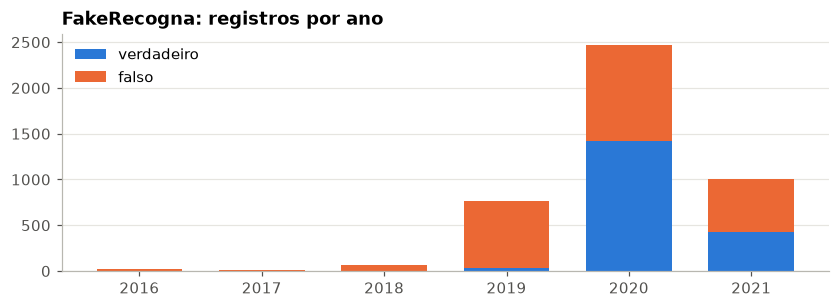

Formato (% dos registros, exceto a 1ª coluna, que é a média de % de palavras em CAIXA ALTA):


,% caixa alta,tem !,curto termina com ponto,curto começa com vídeo/foto,curto em minúsculas
veracidade,,,,,
verdadeiro,1.1,5.2,0.0,0.3,0.4
falso,9.7,54.6,97.7,9.8,0.0


Fontes mais frequentes por classe:


registros
           fonte                               
verdadeiro g1.globo.com                    1060
           uol.com.br                       474
           extra.globo.com                  220
           entretenimento.uol.com.br         63
falso      boatos.org                      2464

Uso no modelo do jogo (split_produto):


split_produto,treino,validacao,teste,reserva,fora
veracidade,,,,,
verdadeiro,0,0,0,1878,2
falso,1959,165,128,212,0


Campos preenchidos (% dos registros):


,titulo,texto_curto,texto,data,autor,url,categoria,veredito_original,par_id
veracidade,,,,,,,,,
verdadeiro,100.0,100.0,100.0,100.0,0.0,100.0,100.0,0.0,0.0
falso,100.0,100.0,100.0,100.0,0.0,100.0,100.0,0.0,0.0


Tabela: 5 registros por classe, como estão no dataset.jsonl (texto cortado em 300 caracteres):


,veracidade,titulo,texto_curto,texto,fonte,data,split_produto
id,,,,,,,
noticia-ac66a8195244,verdadeiro,Carla Prata quebra isolamento para ir ao cabeleireiro,Carla Prata quebra isolamento para ir ao cabeleireiro,"Carla Prata, que estava em isolamento, teve que quebrar sua quarentena para arrumar seus fios do cabelo.\nEla teve que apelar para um profissional, o amigo Guilherme Almeida, para conseguir desembaraçar os fios, que ficaram com um grande nó após ela ter que se desfazer das tranças que tinham fei...",tvefamosos.uol.com.br,2020-03-27,reserva
noticia-b8390a23b452,verdadeiro,Cientistas argentinos desenvolvem teste de coronavírus 'barato e rápido',Cientistas argentinos desenvolvem teste de coronavírus 'barato e rápido',"Cinco cientistas do CONICET, a agência de ciência e técnica do Estado argentino, em colaboração com um laboratório local, desenvolveram um teste molecular para diagnosticar a covid-19 que promete ser mais rápido, mais simples e mais barato do que os atuais.\n""Este teste é importante porque é uma...",uol.com.br,2020-05-19,reserva
noticia-c5d75ed3f8f0,verdadeiro,Refugiados e brasileiros se ajudam para aliviar efeitos da pandemia sobre os mais vulneráveis,Refugiados e brasileiros se ajudam para aliviar efeitos da pandemia sobre os mais vulneráveis,"Refugiados lidam com as barreiras do idioma, do preconceito, das diferenças culturais e com a saudade e a preocupação com quem ficou no país de origem. Em um momento como a pandemia do novo coronavírus , os desafios para essa população aumentam. Iniciativas de brasileiros e dos próprios estrange...",g1.globo.com,2020-06-20,reserva
noticia-6cfe30435ecf,verdadeiro,"K2-141b, o planeta onde chove pedra, os ventos são supersônicos e os oceanos são feitos de lava","K2-141b, o planeta onde chove pedra, os ventos são supersônicos e os oceanos são feitos de lava","Em K2-141b, a chuva é feita de rochas, há um oceano de lava com mais de 100 km de profundidade e os ventos sopram a uma velocidade quatro vezes maior que o som.\n""Este é um planeta muito emocionante , com clima extremo, chuva mineral e neve e vento supersônico"", diz o astrônomo Tue Giang Nguyen ...",g1.globo.com,2020-11-13,reserva
noticia-da13c6ce39e5,verdadeiro,Militares querem que Pazuello passe para a reserva do Exército quando deixar o cargo,Militares querem que Pazuello passe para a reserva do Exército quando deixar o cargo,"BRASÍLIA — A saída do general Eduardo Pazuello do Ministério da Saúde, após dez meses à frente da errática gestão na pandemia da covid-19, foi recebida com alívio por oficiais do Exército. Ainda com o futuro de Pazuello incerto, o maior receio entre os militares agora é sobre a possível volta do...",extra.globo.com,2021-03-17,reserva
boatos-luciano-huck-emprestou-jatinho-para-lula-viajar,falso,"O apresentador Luciano Huck emprestou o seu avião, um jatinho com prefixo PP-HUC, para o ex-presidente Lula viajar de Curitiba para São Paulo.","O apresentador Luciano Huck emprestou o seu avião, um jatinho com prefixo PP-HUC, para o ex-presidente Lula viajar de Curitiba para São Paulo.","BIZARRO ! Luciano Huck, apresentador da #GloboLixo emprestou seu Jatinho, comprado com dinheiro do BNDES, para Lula viajar para São Paulo.\nLuciano Huck, estou ajudando na sua campanha para presidente, canalha !!!!!!!\nLula chega em São Paulo. Adivinha quem emprestou o jatinho?\nOlha quem empres...",boatos.org,2019-11-10,treino
boatos-estudo-nature-prova-ivermectina-cura-covid-19-nao-precisamos-vacinas,falso,Artigo publicado na revista Nature prova que medicamento cura a doença e que não precisamos tomar a vacina contra Covid-19.,Artigo publicado na revista Nature prova que medicamento cura a doença e que não precisamos tomar a vacina contra Covid-19.,"“FINALMENTE! É com muito orgulho que neste instante, com a maior segurança do mundo e sabendo estar dentro da verdade por meio do agora apresentado, eu afirmo ao mundo que… ESTÁVAMOS CERTOS! A maior autoridade em ciência do mundo, a “Nature”, publicou no dia de ho

In [4]:
perfil("FakeRecogna")

## 3. FakeTrue.Br

**O que é.** Corpus do FakeTrueBr (XVIII ERBD, 2023): 1.791 pares de falsa (Boatos.org) e
verdadeira (G1, Folha, UOL) do mesmo assunto. Depois das duplicatas, ficam 812 falsas (979
repetiam o FakeRecogna ou o próprio corpus) e 1.330 verdadeiras (a mesma matéria aparecia em
mais de um par).

**Padrões.**
- **Texto pré-processado na origem**: tudo em minúsculas, sem hífens e com números
  corrompidos ("carnaval de 223"). Isso é uma pista: nenhuma outra base vem em minúsculas.
- **Só as falsas têm texto curto** (o título do boato); as verdadeiras são só o corpo da
  matéria (~370 palavras × ~110 das falsas).
- **Data** sai da URL da verdadeira e vale para o par; 247 registros ficam sem data, mas o
  sorteio por par não depende dela.

,linhas,período,sem data,com texto curto (%),palavras do texto (mediana),palavras do texto curto (mediana)
veracidade,,,,,,
verdadeiro,1330,2007–2023,146,0.0,367.0,NaN
falso,812,2013–2023,101,100.0,108.0,12.0
total,2142,2007–2023,247,38.0,257.0,12.0


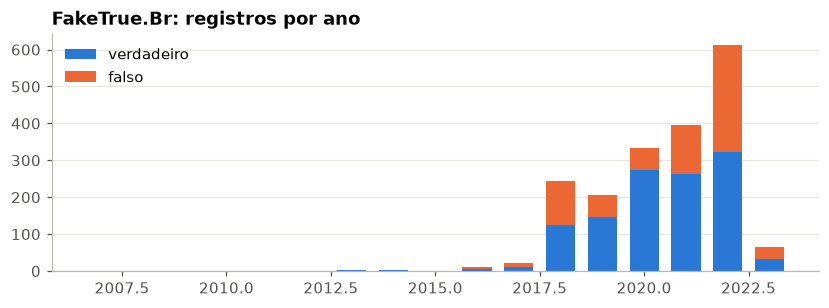

Formato (% dos registros, exceto a 1ª coluna, que é a média de % de palavras em CAIXA ALTA):


,% caixa alta,tem !,curto termina com ponto,curto começa com vídeo/foto,curto em minúsculas
veracidade,,,,,
verdadeiro,0.4,13.5,0.0,0.0,0.0
falso,0.0,47.5,0.0,3.7,100.0


Fontes mais frequentes por classe:


registros
           fonte                            
verdadeiro g1.globo.com                 1085
           noticias.uol.com.br            73
           piaui.folha.uol.com.br         58
           folha.uol.com.br               35
falso      boatos.org                    812

Uso no modelo do jogo (split_produto):


split_produto,treino,validacao,teste,reserva,fora
veracidade,,,,,
verdadeiro,0,0,0,1329,1
falso,645,59,40,66,2


Campos preenchidos (% dos registros):


,titulo,texto_curto,texto,data,autor,url,categoria,veredito_original,par_id
veracidade,,,,,,,,,
verdadeiro,0.0,0.0,100.0,89.0,0.0,100.0,0.0,0.0,100.0
falso,100.0,100.0,100.0,88.0,0.0,100.0,0.0,0.0,100.0


Tabela: 5 registros por classe, como estão no dataset.jsonl (texto cortado em 300 caracteres):


,veracidade,titulo,texto_curto,texto,fonte,data,split_produto
id,,,,,,,
faketrue-true-1708,verdadeiro,NaN,NaN,"Lupa​: “Os números de óbitos anunciados pelas Secretarias de Saúde de Estados com maior índice de mortes por Covid-19 não batem com os registros de óbitos nos cartórios!! ESCÂNDALO!” VERDADEIRO, MAS “Em 2019, entre 1º/Janeiro e 21/Abril, morreram mais de 4.600 pessoas por doenças natureza respir...",piaui.folha.uol.com.br,2020-05-04,reserva
faketrue-true-396,verdadeiro,NaN,NaN,"motoristas da alemanha fizeram uma paralisação com um milhão de carros abandonados para forçar o governo a recuar do aumento do preço do combustível? um post que diz isso foi publicado no facebook e alcançou mais de 3 mil compartilhamentos em um dia. mas ele não é verdadeiro. , a foto usada rem...",g1.globo.com,NaT,reserva
faketrue-true-1209,verdadeiro,NaN,NaN,"foi preso, na manhã desta quarta-feira (16), o suspeito de envolvimento na morte do professor de educação física gustavo roberto da silva, de 36 anos, que foi assassinado a tiros no centro de\xasão luís, no dia 23 de outubro deste ano. , segundo a polícia civil do maranhão, o suspeito, que não ...",g1.globo.com,2022-11-16,reserva
faketrue-true-1365,verdadeiro,NaN,NaN,"os sintomas de gripe e covid-19 inicialmente são parecidos e causam dúvidas na população. no sábado (18), pernambuco confirmou os três primeiros casos de infecção pelo vírus influenza a h3n2, variante que tem causado surtos de gripe em outros estados como rio de janeiro, são paulo e bahia. , a ...",g1.globo.com,2021-12-20,reserva
faketrue-true-1604,verdadeiro,NaN,NaN,"Muitas mulheres se surpreenderam com um vídeo recebido pelo WhatsApp nos últimos dias em que uma mulher, sem se identificar, conta que soube, pelo médico Dráuzio Varella, que a incidência de câncer de tireoide pode ter aumentado devido à exposição a radiação em exames de mamografia e raios-X den...",noticias.uol.com.br,2016-10-08,reserva
faketrue-fake-639,falso,lula acaba de declarar que vai fechar igrejas em 223,lula acaba de declarar que vai fechar igrejas em 223,"atenção! lula acaba de declarar que ira fechar igrejas em 223, isso é muito serio igreja. lula 13 @lula oficial em 223, quando eu assumir a presidência, as igrejas evangélicas e católicas terão que seguir a lei, nos vamos obrigá-los a casar pessoas da comunidade lgbt, chega de homofobia! 12:53 p...",boatos.org,2022-10-07,treino
faketrue-fake-1022,falso,jair bolsonaro propõe demissão em massa de professores do brasil,jair bolsonaro propõe demissão em massa de professores do brasil,"“bolsonaro propõe demissão em massa de professores e ensino à distância para todos os níveis , sem nenhum conhecimento técnico do sistema de educação, o presidenciável jair bolsonaro (psl) prometeu demitir professores em massa e acabar com a escola presencial e instituir o ensino à distância par...",boatos.org,2022-07-15,treino
faketrue-fake-1549,falso,"lulinha desfila com ferrari dourada no uruguai, mostra video","lulinha desfila com ferrari dourada no uruguai, mostra video","filho do lula com uma ferrari dourada no uruguai? e voce vai ficar parado? vai deixar isso acontecer na sua frente? e nao vai fazer nada? compartilhe esse video e vamos mostrar ao brasil quem e o lula e sua familia!video que circula na web mostra, supostamente, o filho de lula, em uma ferrari do...",boatos.org,2017-07-25,reserva
faketrue-fake-1084,falso,alexandre kalil anuncia fechamento do comércio em belo horizonte a partir de sábado (janeiro de 222),alexandre kalil anuncia fechamento do comércio em belo horizonte a partir de sábado (janeiro de 222),belo horizonte e são números absolutamente assustadores como nós não fechamos a cidade e no dia seguinte o número caiu um por cento eu pessoalmente fui tomado por um otimismo enganoso o e perigoso mas hoje e nós detectamos uma alta de sete porcento nos nossos números e isso nos põe e em sinal de...,boatos.org,2021-01-06,treino


In [5]:
perfil("FakeTrue.Br")

## 4. Fact Check API

**O que é.** Alegações checadas por 10 agências brasileiras, coletadas pela Google Fact Check
Tools API. É a principal fonte de **enganosos** (o meio da escala) e de checagens recentes.

**Padrões.**
- **Quase não tem verdadeiros** (94): as agências checam o que é suspeito.
- **Formato homogêneo**: as três classes são alegações curtas (~12 palavras), no mesmo
  estilo, então aqui o formato não entrega a classe.
- **Uso por data**: até 2023 ensina o enganoso no treino; 2024 é a validação; 2025 em diante,
  o teste. A maior parte das checagens recentes fica na validação e no teste.

,linhas,período,sem data,com texto curto (%),palavras do texto (mediana),palavras do texto curto (mediana)
veracidade,,,,,,
verdadeiro,111,2015–2026,0,100.0,14.0,14.0
enganoso,3017,2015–2026,0,100.0,13.0,12.0
falso,7971,2015–2026,0,100.0,12.0,12.0
total,11099,2015–2026,0,100.0,12.0,12.0


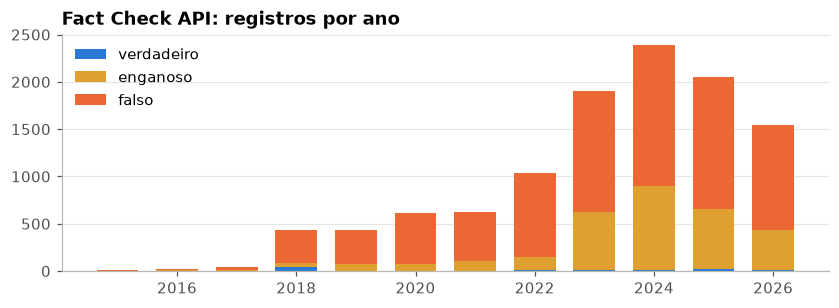

Formato (% dos registros, exceto a 1ª coluna, que é a média de % de palavras em CAIXA ALTA):


,% caixa alta,tem !,curto termina com ponto,curto começa com vídeo/foto,curto em minúsculas
veracidade,,,,,
verdadeiro,1.3,0.9,16.2,1.8,0.9
enganoso,2.8,2.9,14.8,7.9,0.2
falso,3.2,3.6,11.7,9.4,0.2


Fontes mais frequentes por classe:


registros
           fonte                           
verdadeiro eleicoes.apublica.org         38
           noticias.uol.com.br           38
           aosfatos.org                  13
           checamos.afp.com               7
enganoso   estadao.com.br              1394
           noticias.uol.com.br          768
           checamos.afp.com             417
           aosfatos.org                 185
falso      noticias.uol.com.br         3042
           aosfatos.org                1993
           estadao.com.br              1317
           checamos.afp.com            1257

Uso no modelo do jogo (split_produto):


split_produto,treino,validacao,teste,reserva,fora
veracidade,,,,,
verdadeiro,71,10,29,0,1
enganoso,1064,892,1054,0,7
falso,3969,1006,1239,1744,13


Campos preenchidos (% dos registros):


,titulo,texto_curto,texto,data,autor,url,categoria,veredito_original,par_id
veracidade,,,,,,,,,
verdadeiro,0.0,100.0,100.0,100.0,94.0,100.0,0.0,100.0,0.0
enganoso,0.0,100.0,100.0,100.0,97.0,100.0,0.0,100.0,0.0
falso,0.0,100.0,100.0,100.0,98.0,100.0,0.0,100.0,0.0


Tabela: 5 registros por classe, como estão no dataset.jsonl (texto cortado em 300 caracteres):


,veracidade,titulo,texto_curto,texto,fonte,data,split_produto
id,,,,,,,
factcheck-552c245ebdab,verdadeiro,NaN,"Se desconsiderarmos o aumento do gasto com energia elétrica, conseguimos reduzir em 10,2%, reais, as despesas de custeio do conjunto do governo federal em 2015.","Se desconsiderarmos o aumento do gasto com energia elétrica, conseguimos reduzir em 10,2%, reais, as despesas de custeio do conjunto do governo federal em 2015.…",aosfatos.org,2016-02-02,treino
factcheck-106f43861598,verdadeiro,NaN,'40% do esgoto que é captado é jogado no Rio Tietê.”,'40% do esgoto que é captado é jogado no Rio Tietê.”…,eleicoes.apublica.org,2018-10-05,treino
factcheck-bf914aec4d71,verdadeiro,NaN,Como funciona o golpe do falso emprego,Como funciona o golpe do falso emprego…,noticias.uol.com.br,2025-01-01,teste
factcheck-0985000714b9,verdadeiro,NaN,Foto de Flávio Bolsonaro ao lado de Donald Trump na Casa Branca em maio de 2026,Foto de Flávio Bolsonaro ao lado de Donald Trump na Casa Branca em maio de 2026…,noticias.uol.com.br,2026-01-01,teste
factcheck-fad491a92067,verdadeiro,NaN,"Hélio Lopes, isso mesmo, o ?amigão? do Bolsonaro, deputado de EXTREMÍSSIMA DIREITA, resolveu convocar uma audiência pública sobre a chamada ?PEC do Fim dos Pardos?.","Hélio Lopes, isso mesmo, o ?amigão? do Bolsonaro, deputado de EXTREMÍSSIMA DIREITA, resolveu convocar uma audiência pública sobre a chamada ?PEC do Fim dos Pardos?.…",noticias.uol.com.br,2025-01-01,teste
factcheck-8162d7e0997c,enganoso,NaN,Volkswagen anunciou fechamento de todas as fábricas do Brasil,Volkswagen anunciou fechamento de todas as fábricas do Brasil…,estadao.com.br,2023-07-06,treino
factcheck-42f387e4368c,enganoso,NaN,"Mortes na pandemia em Taiwan, Austrália e Japão mostram que as vacinas contra a covid-19 não são eficazes","Mortes na pandemia em Taiwan, Austrália e Japão mostram que as vacinas contra a covid-19 não são eficazes…",estadao.com.br,2023-10-18,treino
factcheck-78e5e7762225,enganoso,NaN,Humilhação: Lula é ignorado por Biden após seu pronunciamento. Deixe sua opinião!,Humilhação: Lula é ignorado por Biden após seu pronunciamento. Deixe sua opinião!…,noticias.uol.com.br,2023-01-01,treino
factcheck-500ae5760ae2,enganoso,NaN,VAI VENDO: A nadadora TRANSGÊNERO Lia Thomas é PROIBIDA de participar de competições FEMININAS para sempre! Você considera justa esta medida?,VAI VENDO: A nadadora TRANSGÊNERO Lia Thomas é PROIBIDA de participar de competições FEMININAS para sempre! Você considera justa esta medida?…,noticias.uol.com.br,2024-01-01,validacao


In [6]:
perfil("Fact Check API")

## 5. FakenewsBR (agências)

**O que é.** Sub-bases de agências da FakenewsBR v6 (e-farsas, G1 Fato ou Fake, Lupa, Coletivo
Bereia, SBT...). Entram os enganosos e os verdadeiros checados; os falsos são amostrados por
agência (até o maior entre os enganosos e os verdadeiros dela), senão a agência viraria
pista de "não é falso".

**Padrões.**
- **Os verdadeiros são checados** e têm o mesmo formato das falsas: é o melhor tipo de
  verdadeiro que temos, mas são poucos (603), quase todos do e-farsas.
- **Muitos falsos ficam de fora**: dos 15.571, a maior parte vai para `reserva` no
  equilíbrio, e os sem data ou anteriores a 2016 vão para `fora`.

,linhas,período,sem data,com texto curto (%),palavras do texto (mediana),palavras do texto curto (mediana)
veracidade,,,,,,
verdadeiro,599,2010–2026,0,100.0,11.0,11.0
enganoso,612,2018–2026,14,100.0,12.0,12.0
falso,15592,2010–2026,15,94.0,15.0,14.0
total,16803,2010–2026,29,95.0,15.0,14.0


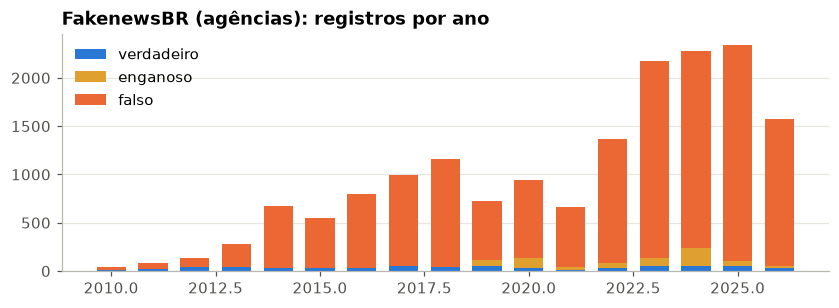

Formato (% dos registros, exceto a 1ª coluna, que é a média de % de palavras em CAIXA ALTA):


,% caixa alta,tem !,curto termina com ponto,curto começa com vídeo/foto,curto em minúsculas
veracidade,,,,,
verdadeiro,1.1,14.2,0.2,13.2,5.0
enganoso,1.9,4.2,3.6,12.1,0.3
falso,3.0,7.7,1.8,13.3,2.6


Fontes mais frequentes por classe:


registros
           fonte                           
verdadeiro e-farsas.com                 431
           g1.globo.com                 112
           coletivobereia.com.br         29
           lupa.uol.com.br               19
enganoso   e-farsas.com                 159
           checamos.afp.com             132
           coletivobereia.com.br        127
           sbtnews.sbt.com.br            87
falso      boatos.org                  8308
           e-farsas.com                2618
           g1.globo.com                2450
           lupa.uol.com.br             1298

Uso no modelo do jogo (split_produto):


split_produto,treino,validacao,teste,reserva,fora
veracidade,,,,,
verdadeiro,298,50,81,0,170
enganoso,333,187,78,0,14
falso,405,128,146,13303,1610


Campos preenchidos (% dos registros):


,titulo,texto_curto,texto,data,autor,url,categoria,veredito_original,par_id
veracidade,,,,,,,,,
verdadeiro,0.0,100.0,100.0,100.0,5.0,100.0,0.0,100.0,0.0
enganoso,0.0,100.0,100.0,98.0,52.0,100.0,0.0,100.0,0.0
falso,0.0,94.0,100.0,100.0,17.0,100.0,0.0,100.0,0.0


Tabela: 5 registros por classe, como estão no dataset.jsonl (texto cortado em 300 caracteres):


,veracidade,titulo,texto_curto,texto,fonte,data,split_produto
id,,,,,,,
fakenewsbr-628772886591277934,verdadeiro,NaN,Vídeo mostra uma enxurrada de vinho percorrendo as ruas de Portugal! Será verdade,Vídeo mostra uma enxurrada de vinho percorrendo as ruas de Portugal! Será verdade…,e-farsas.com,2023-09-14,treino
fakenewsbr-158347145026978728,verdadeiro,NaN,Mãe pede ajuda para filha com Amiotrofia Muscular Espinhal pelo WhatsApp! Será,Mãe pede ajuda para filha com Amiotrofia Muscular Espinhal pelo WhatsApp! Será…,e-farsas.com,2018-10-10,treino
fakenewsbr-794622795306823643,verdadeiro,NaN,Família pede denúncia de vídeo que mostra morte durante batismo em rio,Família pede denúncia de vídeo que mostra morte durante batismo em rio…,coletivobereia.com.br,2021-04-08,treino
fakenewsbr-1127616331795429590,verdadeiro,NaN,vídeo que mostra cachorro escondendo pintinho na boca,vídeo que mostra cachorro escondendo pintinho na boca…,g1.globo.com,2025-03-26,teste
fakenewsbr-478249917213030258,verdadeiro,NaN,Tragédia: Chegada do Papai Noel de paraquedas em Mogi das Cruzes,Tragédia: Chegada do Papai Noel de paraquedas em Mogi das Cruzes…,e-farsas.com,2016-11-08,treino
fakenewsbr-637773487030675394,enganoso,NaN,Lula assumiu o comunismo,Lula assumiu o comunismo…,sbtnews.sbt.com.br,2024-10-03,validacao
fakenewsbr-30295920785130171,enganoso,NaN,Mensagem em grupos religiosos engana e cria alarde sobre fechamento de igrejas na Nicarágua,Mensagem em grupos religiosos engana e cria alarde sobre fechamento de igrejas na Nicarágua…,coletivobereia.com.br,2024-08-27,validacao
fakenewsbr-638854882567935823,enganoso,NaN,Fotos mostram um bebê morcego albino! Será verdade,Fotos mostram um bebê morcego albino! Será verdade…,e-farsas.com,2020-06-20,treino
fakenewsbr-689037941064617351,enganoso,NaN,Autoridades do Irã anunciaram a suspensão do uso obrigatório do hijab pelas mulheres,Autoridades do Irã anunciaram a suspensão do uso obrigatório do hijab pelas mulheres…,aosfatos.org,2025-10-09,teste


In [7]:
perfil("FakenewsBR (agências)")

## 6. FakenewsBR (mensagens)

**O que é.** Mensagens anotadas da FakenewsBR: FakeWhatsApp.BR (grupos de WhatsApp na eleição
de 2018) e COVID19.BR (2020, sem data). Entram as duas classes, só no treino.

**Padrões.**
- **Mesmo formato nas duas classes** (mensagem de rede social), o que ajuda contra o atalho
  "manchete = verdadeiro".
- **Rótulo com ruído**: "verdadeiro" aqui quer dizer "não é desinformação", e inclui
  correntes e comentários. Por isso entram com `origem_rotulo = mensagem` (peso 0,7).
- **Pouco texto curto** (~25%): a maioria é mensagem longa.

,linhas,período,sem data,com texto curto (%),palavras do texto (mediana),palavras do texto curto (mediana)
veracidade,,,,,,
verdadeiro,3928,2018–2018,1087,28.0,27.0,31.0
enganoso,2,2018–2018,1,50.0,19.0,12.0
falso,3151,2018–2018,740,23.0,44.0,48.0
total,7081,2018–2018,1828,26.0,33.0,40.0


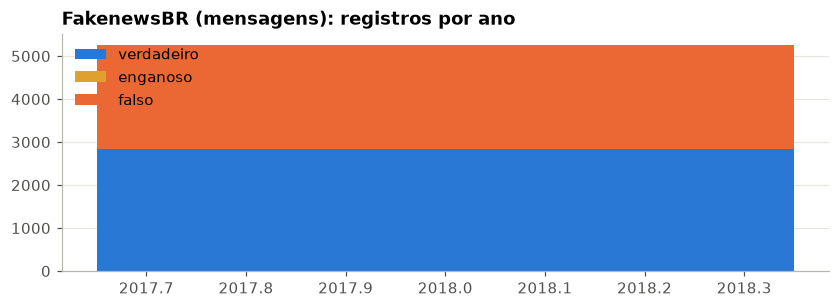

Formato (% dos registros, exceto a 1ª coluna, que é a média de % de palavras em CAIXA ALTA):


,% caixa alta,tem !,curto termina com ponto,curto começa com vídeo/foto,curto em minúsculas
veracidade,,,,,
verdadeiro,8.1,29.1,6.3,0.0,0.2
enganoso,0.0,50.0,0.0,0.0,0.0
falso,10.9,46.2,7.5,0.0,0.0


Fontes mais frequentes por classe:


registros
           fonte                          
verdadeiro FakeWhatsApp.BR_2018       2841
           COVID19.BR                 1087
enganoso   FakeWhatsApp.BR_2018          1
           COVID19.BR                    1
falso      FakeWhatsApp.BR_2018       2411
           COVID19.BR                  740

Uso no modelo do jogo (split_produto):


split_produto,treino
veracidade,
verdadeiro,3928
enganoso,2
falso,3151


Campos preenchidos (% dos registros):


,titulo,texto_curto,texto,data,autor,url,categoria,veredito_original,par_id
veracidade,,,,,,,,,
verdadeiro,0.0,28.0,100.0,72.0,0.0,0.0,0.0,0.0,0.0
enganoso,0.0,50.0,100.0,50.0,100.0,0.0,0.0,100.0,0.0
falso,0.0,23.0,100.0,77.0,0.0,0.0,0.0,0.0,0.0


Tabela: 5 registros por classe, como estão no dataset.jsonl (texto cortado em 300 caracteres):


,veracidade,titulo,texto_curto,texto,fonte,data,split_produto
id,,,,,,,
fakenewsbr-17081,verdadeiro,NaN,NaN,"*_MUITO BOM DIA AMIGOS_.*\n*_QUE DEUS NOS PROTEJA_.*\n\n*_""BRASIL ACIMA DE TUDO DEUS ACIMA DE TODOS""""_*\n🙏🙏🙏🙌🙌🙌🇧🇷🇧🇷🇧🇷🇧🇷\n💦💧💦💧💦💧💦💧💦💧…",FakeWhatsApp.BR_2018,2018-10-17,treino
fakenewsbr-12290,verdadeiro,NaN,NaN,O Haddad chegou pra mulher dele e disse: \n- querida segunda-feira depois do segundo turno vc vai dormir com o presidente da republica. Ela respondeu:\n- o Bolsonaro vem aqui ou tenho que ir na casa dele???\n🤗🤗😉😉😉😉…,FakeWhatsApp.BR_2018,2018-08-10,treino
fakenewsbr-15175,verdadeiro,NaN,NaN,"Boa noite , estamos na reta final de uma campanha que vai marcar pra Sempre a história do Brasil.\nA maior campanha que o Brasil já viu foi feita por amor a Pátria.\nFico orgulhosa de fazer parte desse momento junto com cada um de vocês.\nDia 07 é 17 presidente \nDia 07 é 170 senador.…",FakeWhatsApp.BR_2018,2018-09-24,treino
fakenewsbr-12643,verdadeiro,NaN,NaN,"Consulta pública dos processos em 1o grau no Site do TJSP. Nome: Fernando Haddad.\nO cinco primeiros processos são de improbidade administrativa, incluindo enriquecimento ilícito, dano ao erário, e violação de preceito fundamental da Administração Pública. Esse é o candidato do PT à presidência ...",FakeWhatsApp.BR_2018,2018-09-20,treino
fakenewsbr-15739,verdadeiro,NaN,NaN,O Sérgio Moro na platéia e o cara fez um stand-up com o próprio interrogando o Lula...…,FakeWhatsApp.BR_2018,2018-10-26,treino
fakenewsbr-12863,enganoso,NaN,NaN,"Haddad diz que a eleição ja Acabou, agora pede dinheiro para os eleitores.\nVamos Fazer este vídeo rodar o Brasil inteiro de Hoje Para Amanhã!…",FakeWhatsApp.BR_2018,2018-07-09,treino
fakenewsbr-1579,enganoso,NaN,"Liberação da Cloroquina pela Anvisa, já com posologia para tratamento do Covid-19:","Liberação da Cloroquina pela Anvisa, já com posologia para tratamento do Covid-19:…",COVID19.BR,NaT,treino
fakenewsbr-10885,falso,NaN,NaN,"Saiu o resultado sobre as urnas: *SIM, houve FRAUDE*! \n\nE se não formos para as ruas, *Haddad será o presidente*!…",FakeWhatsApp.BR_2018,2018-10-14,treino
fakenewsbr-11982,falso,NaN,NaN,"Bolsonaro começou a semana com 60/40, ontem o Ibope soltou uma pesquisa 58/42. Eu disse que iam reduzir até o final da semana. Hoje o Datafolha soltou 56/44. \nEntão, agora, vou explicar como vai funcionar. Amanhã, sexta, vão liberar uma pesquisa 54/46. No sábado será 52/48. Com margem de erro d...",FakeWhatsApp.BR_2018,2018-10-24,treino


In [8]:
perfil("FakenewsBR (mensagens)")

## 7. Portais

**O que é.** Matérias de 9 portais de linhas editoriais variadas, coletadas pela API
WordPress (`coletar_verdadeiras.py`), de 2018 a 2026. Verdadeiras **por suposição** (não
checadas), com `origem_rotulo = portal` (peso 0,7).

**Padrões.**
- **Volume grande e estável** (~2.500 por portal), então servem para completar os
  verdadeiros: no treino, só até igualar os falsos; na validação e no teste, cobrem 2024 em
  diante, que nenhuma outra base cobre. O resto (16.876) fica em `reserva`.
- **Formato de manchete**: texto curto sem ponto final e matéria longa (~360 palavras).

,linhas,período,sem data,com texto curto (%),palavras do texto (mediana),palavras do texto curto (mediana)
veracidade,,,,,,
verdadeiro,21284,2018–2026,0,100.0,364.0,11.0
total,21284,2018–2026,0,100.0,364.0,11.0


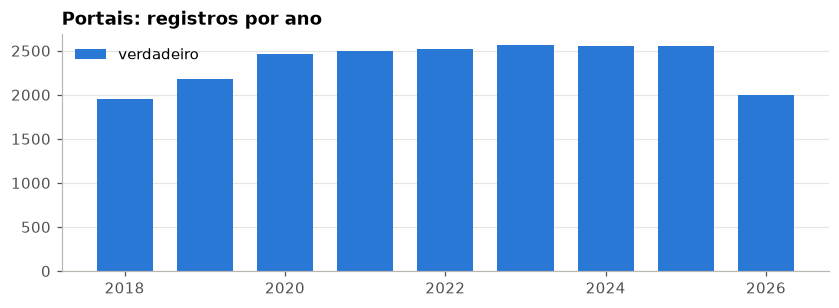

Formato (% dos registros, exceto a 1ª coluna, que é a média de % de palavras em CAIXA ALTA):


,% caixa alta,tem !,curto termina com ponto,curto começa com vídeo/foto,curto em minúsculas
veracidade,,,,,
verdadeiro,1.3,9.4,0.0,0.4,0.2


Fontes mais frequentes por classe:


registros
           fonte                         
verdadeiro poder360.com.br           2522
           infomoney.com.br          2521
           veja.abril.com.br         2503
           brasildefato.com.br       2500

Uso no modelo do jogo (split_produto):


split_produto,reserva,fora
veracidade,,
verdadeiro,21254,30


Campos preenchidos (% dos registros):


,titulo,texto_curto,texto,data,autor,url,categoria,veredito_original,par_id
veracidade,,,,,,,,,
verdadeiro,100.0,100.0,100.0,100.0,0.0,100.0,100.0,0.0,0.0


Tabela: 5 registros por classe, como estão no dataset.jsonl (texto cortado em 300 caracteres):


,veracidade,titulo,texto_curto,texto,fonte,data,split_produto
id,,,,,,,
verdadeira-jornalusp-559463,verdadeiro,Brasileira que salvou judeus durante Holocausto é tema de evento,Brasileira que salvou judeus durante Holocausto é tema de evento,"O Instituto de Estudos Brasileiros (IEB) da USP promove no dia 12, segunda-feira, das 18 às 20 horas, a c onferência Aracy de Carvalho Tess e a Imigração de Judeus no Brasil Varguista (1938-1941) . A apresentação contará com a presença d a historiadora Mônica Raisa Schpun, autora do livro Justa:...",jornal.usp.br,2022-09-09,reserva
verdadeira-veja-3938380,verdadeiro,Biden sanciona projeto de infraestrutura de 1 trilhão de dólares,Biden sanciona projeto de infraestrutura de 1 trilhão de dólares,"Joe Biden, presidente dos Estados Unidos, sancionou um projeto de lei de infraestrutura de 1 trilhão de dólares nesta segunda-feira, 15, em uma cerimônia na Casa Branca que juntou democratas e republicanos que atuaram para fazer avançar a legislação em um Congresso profundamente dividido.\nA med...",veja.abril.com.br,2021-11-15,reserva
verdadeira-jovempan-276436,verdadeiro,"Principal qualidade de Flávio Bolsonaro é sua ‘certidão de nascimento’, diz Kassab","Principal qualidade de Flávio Bolsonaro é sua ‘certidão de nascimento’, diz Kassab","O presidente do Partido Social Democrático (PSD), Gilberto Kassab , afirmou neste sábado (15) que a “principal qualidade” do candidato à Presidência Flávio Bolsonaro (PL) é a sua “certidão de nascimento” . A declaração foi dada em entrevista exclusiva ao Jornal Jovem Pan .\nAo comentar sobre a d...",jovempan.com.br,2026-08-15,reserva
verdadeira-brasildefato-1026865,verdadeiro,Tornozeleiras para indígenas ameaçados em disputa territorial: a escalada do conflito do dendê no Pará,Tornozeleiras para indígenas ameaçados em disputa territorial: a escalada do conflito do dendê no Pará,"Em decisão publicada em 1º de setembro de 2026 pela juíza Maria Natalice Oliveira Felipe, do Tribunal de Justiça do Pará, o Poder Judiciário indeferiu o pedido de prisão preventiva por “extorsão mediante sequestro”, movido pela Polícia Civil do Pará, mas impôs medidas cautelares severas a quatro...",brasildefato.com.br,2026-09-25,reserva
verdadeira-jovempan-3522,verdadeiro,Moraes arquiva inquérito contra Elon Musk após pedido da PGR,Moraes arquiva inquérito contra Elon Musk após pedido da PGR,"O ministro Alexandre de Moraes , do Supremo Tribunal Federal (STF), acolheu nesta terça-feira (10) pedido da Procuradoria-Geral da República (PGR) para arquivar inquérito contra o dono do X (ex-Twitter), Tesla e SpaceX, Elon Musk . O empresário era investigado por obstrução de Justiça, organizaç...",jovempan.com.br,2026-03-10,reserva


In [9]:
perfil("Portais")

## 8. ClaimPT (fora do dataset)

Notícias da Lusa (português europeu) com afirmações, não-afirmações e quem disse. **Não tem veracidade**, então fica em `claimpt.jsonl`, para avaliar a extração de afirmações pela LLM. O repositório público traz só uma amostra de 20 artigos; o completo exige um Data Use Agreement.

In [10]:
claimpt = pd.read_json(RAIZ / "data" / "processed" / "claimpt.jsonl", lines=True)
afirm = claimpt.explode("afirmacoes").afirmacoes.dropna()
print(f"{len(claimpt)} artigos · {claimpt.afirmacoes.str.len().sum()} afirmações · "
      f"{claimpt.nao_afirmacoes.str.len().sum()} não-afirmações · amostra: {claimpt.amostra.all()}")
pd.DataFrame({"trecho": afirm.str["trecho"].str[:90], "quem disse": afirm.str["quem_disse"].str[0].str["texto"]}).head(8)

20 artigos · 16 afirmações · 68 não-afirmações · amostra: True


,trecho,quem disse
0,"foi convidado para aderir não pelo lado monárquico, no qual, aliás, não insistiam muito, m",Pinto Balsemão
3,"Infelizmente, a rejeição da existência de Israel é um elemento comum entre ambas as fações",o primeiro-ministro israelita
6,"Setenta e cinco anos depois, os judeus ainda são alvo de ataques e ainda sentem a violênci",Yeela Cytrin
6,O Hamas e os seus apoiantes encorajam a erradicação do povo judeu nas redes sociais há ano,Yeela Cytrin
6,"Mesmo antes de os corpos das vítimas de 07 de outubro arrefecerem, o antissemitismo explod",Yeela Cytrin
6,"Nas últimas oito semanas, depois de transmitir publicamente apelos genocidas, Israel começ",A diplomata palestiniana Dima Asfour
7,"A maioria absoluta fechou hospitais e urgências, deixou Portugal numa crise de habitação e",Mariana Mortágua
7,"Estamos na estação da universidade que é o fim de linha do metro sul do Tejo, deixando mil",Mariana Mortágua


## Resumo dos padrões

| Dataset | Formato das classes | Atalho principal | Papel |
|---|---|---|---|
| Fake.br | matéria × matéria | um site só nas falsas (tamanho igualado pelo corpus) | verdadeiro e falso pareados |
| FakeRecogna | mensagem × matéria | ponto final, `!`, caixa alta, tamanho | verdadeiro e falso |
| FakeTrue.Br | mensagem × matéria | texto em minúsculas; tamanho | verdadeiro e falso pareados |
| Fact Check API | alegação × alegação | — (formato homogêneo) | enganoso e falso; checagens recentes |
| FakenewsBR (agências) | alegação × alegação | agência sem falsos (corrigido com amostra) | verdadeiros checados e enganosos |
| FakenewsBR (mensagens) | mensagem × mensagem | — (mesmo formato) | verdadeiro e falso no mesmo gênero |
| Portais | manchete/matéria | gênero de texto | verdadeiros recentes |

Os atalhos de formato e tamanho reforçam a decisão de padronizar o texto pela LLM, igual no treino e no uso, e de medir o teste de atalho no conjunto (`eda_2_conjunto.ipynb`).